# Bus OD Matrix Combined with OnBoard Survey Probabilities

`Input/6_9_BusProbability_ByTAZ.xlsx` (OnBoard survey) gives P(alight at `toTAZ` | board at `fromTAZ`) for the 6:00–9:00 window, with rows summing exactly to 1 per origin — including a `toTAZ = NaN` share (unknown alighting, median 7.4% where present).

1. **Probability matrix**: NaN destinations are dropped and each origin row renormalized to sum to 1 over known destinations.
2. **Combined ("new") matrix**: each origin's total from the RavKav OD matrix (`Output/bus/bus_od_taz_avg.csv` row sums, average Tuesday) is distributed over destinations by the OnBoard probabilities — RavKav sets the volumes, the OnBoard survey sets the destination pattern. Origins the OnBoard file does not cover (5.0% of volume) keep their RavKav row unchanged as a fallback.

In [1]:
import numpy as np
import pandas as pd

ob = pd.read_excel('Input/6_9_BusProbability_ByTAZ.xlsx')
assert np.allclose(ob.groupby('fromTAZ')['Probability'].sum(), 1.0)

known = ob.dropna(subset=['toTAZ']).copy()
known['toTAZ'] = known['toTAZ'].astype(int)
P = known.pivot_table(index='fromTAZ', columns='toTAZ', values='Probability', aggfunc='sum').fillna(0)
row_sums = P.sum(axis=1)
P = P[row_sums > 0].div(row_sums[row_sums > 0], axis=0)   # renormalize over known destinations
P.index = P.index.astype(int)
P.index.name = 'fromTAZ'
P.to_csv('Output/bus/bus_probability_matrix.csv', float_format='%.6g')
dropped = (row_sums <= 0).sum()
print(f"probability matrix: {P.shape}, rows sum to 1 (renormalized; unknown-destination share removed)")
print(f"origins dropped for having only unknown destinations: {dropped}")

probability matrix: (594, 548), rows sum to 1 (renormalized; unknown-destination share removed)
origins dropped for having only unknown destinations: 0


In [2]:
rav = pd.read_csv('Output/bus/bus_od_taz_avg.csv', index_col=0)
rav.index = rav.index.astype(int)
rav.columns = rav.columns.astype(int)

all_dest = sorted(set(rav.columns) | set(P.columns))
new = pd.DataFrame(0.0, index=rav.index, columns=all_dest)
vol = rav.sum(axis=1)

onboard_vol = fallback_vol = 0.0
for o in rav.index:
    if o in P.index:
        new.loc[o, P.columns] = vol[o] * P.loc[o].values
        onboard_vol += vol[o]
    else:
        new.loc[o, rav.columns] = rav.loc[o].values
        fallback_vol += vol[o]

new.index.name = 'orig_taz'
new.to_csv('Output/bus/bus_od_taz_new.csv', float_format='%.6g')
assert abs(new.values.sum() - rav.values.sum()) < 0.5
print(f"new matrix: {new.shape}, total {new.values.sum():,.0f} passengers/avg Tuesday (preserved)")
print(f"volume redistributed by OnBoard probabilities: {onboard_vol:,.0f} ({onboard_vol / vol.sum():.1%}) | "
      f"RavKav fallback: {fallback_vol:,.0f} ({fallback_vol / vol.sum():.1%})")

# how different are the two destination patterns?
common_o = [o for o in rav.index if o in P.index]
common_d = sorted(set(rav.columns) & set(P.columns))
a = rav.loc[common_o, common_d].div(rav.loc[common_o].sum(axis=1), axis=0).fillna(0)
b = new.loc[common_o, common_d].div(new.loc[common_o].sum(axis=1), axis=0).fillna(0)
r = np.corrcoef(a.values.flatten(), b.values.flatten())[0, 1]
print(f"correlation between RavKav and OnBoard destination distributions (common cells): r = {r:.4f}")

new matrix: (722, 728), total 143,402 passengers/avg Tuesday (preserved)
volume redistributed by OnBoard probabilities: 135,533 (94.5%) | RavKav fallback: 7,869 (5.5%)
correlation between RavKav and OnBoard destination distributions (common cells): r = 0.0846


## Aggregation to the 28 areas and comparison with the THS TRANSIT matrix

The combined bus matrix is restricted to the 205 sub-area TAZs (`Input/Submatrix_tazs.xlsx`, both ends) and aggregated to the 28 `AggAreaCode` areas — the same system as `matrix_avg_TRANSIT_area.csv` — then the two are compared: RavKav×OnBoard measures actual bus ticketing at full scale; THS TRANSIT is residents' reported bus-type trips expanded by survey weights.

In [3]:
sub_key = pd.read_excel('Input/Submatrix_tazs.xlsx')
taz_to_area = sub_key.set_index('TAZ')['AggAreaCode']
AREAS = sorted(sub_key['AggAreaCode'].unique())
legend = sub_key.drop_duplicates('AggAreaCode').set_index('AggAreaCode')['AggAreaName']

def to_area(m):
    m = m.copy()
    m.index.name, m.columns.name = 'o', 'd'
    long = m.stack().reset_index()
    long.columns = ['o', 'd', 'v']
    long['O'] = long['o'].map(taz_to_area)
    long['D'] = long['d'].map(taz_to_area)
    return (long.dropna(subset=['O', 'D']).groupby(['O', 'D'])['v'].sum()
            .unstack().reindex(index=AREAS, columns=AREAS, fill_value=0).fillna(0))

bus_area = to_area(new)
bus_area.index.name = 'AggAreaCode'
bus_area.to_csv('Output/bus/bus_od_area_new.csv', float_format='%.6g')
print(f"bus_od_area_new.csv: {bus_area.shape}, {bus_area.values.sum():,.0f} avg-Tuesday bus passengers in the sub-area "
      f"({bus_area.values.sum() / new.values.sum():.1%} of the in-study bus total)")

bus_od_area_new.csv: (28, 28), 41,351 avg-Tuesday bus passengers in the sub-area (28.8% of the in-study bus total)


totals: RavKav x OnBoard = 41,351 | THS TRANSIT = 26,247 (ratio 1.58)
cell correlation (counts): r = 0.7559 | row-distribution correlation: r = 0.1667

origin totals by area (top 12 by bus volume):
              AggAreaName  bus_origins  ths_origins  ratio
25  Kiryat Motzkin-Bialik       9584.0       6021.0   1.59
24             Kiryat Yam       6714.0       4268.0   1.57
28       Kiryat Ata South       3435.0       3235.0   1.06
16      Kiryat Ata Center       2642.0        686.0   3.85
23          Nazareth Area       2492.0       1585.0   1.57
13              Hamifrats       2213.0        120.0  18.44
4              Neve David       2160.0       1318.0   1.64
1             TiratCarmel       2086.0       1188.0   1.76
12             Neve Yosef       1601.0        525.0   3.05
7          Kiryat Eliezer       1241.0        708.0   1.75
9              Lower City       1026.0        262.0   3.92
27           Nesher Lower        894.0        491.0   1.82


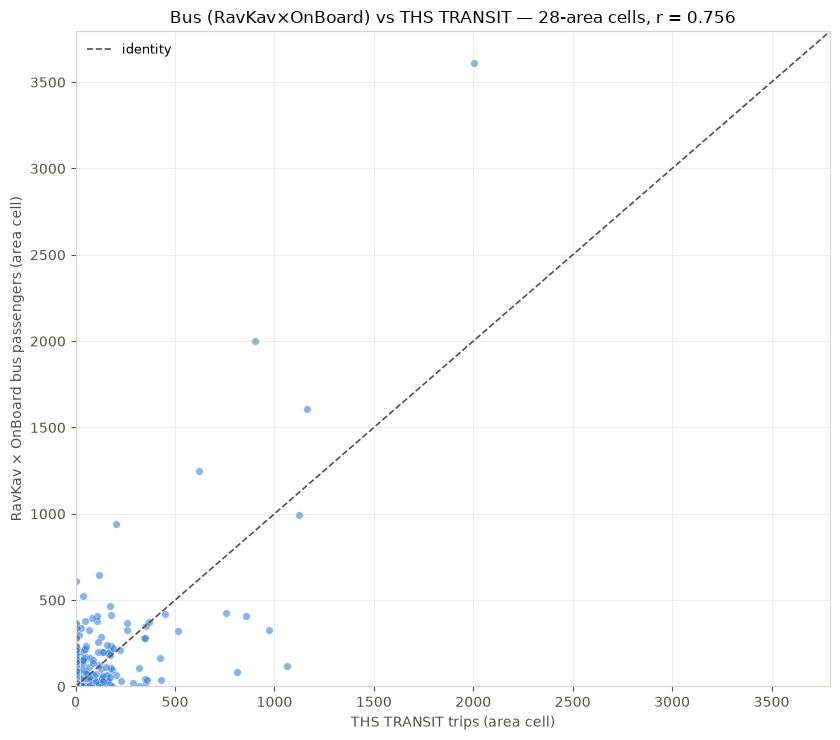

In [4]:
import matplotlib.pyplot as plt
BLUE, INK, INK2 = '#2a78d6', '#0b0b0b', '#52514e'

ths = pd.read_csv('Output/ths2017/study_taz/submatrices/matrix_avg_TRANSIT_area.csv', index_col=0)
ths.index = ths.index.astype(int)
ths.columns = ths.columns.astype(int)
ths = ths.reindex(index=AREAS, columns=AREAS, fill_value=0)

b, t = bus_area.values.flatten(), ths.values.flatten()
r_counts = np.corrcoef(b, t)[0, 1]
bp = bus_area.div(bus_area.sum(axis=1).replace(0, np.nan), axis=0).fillna(0).values.flatten()
tp = ths.div(ths.sum(axis=1).replace(0, np.nan), axis=0).fillna(0).values.flatten()
r_prob = np.corrcoef(bp, tp)[0, 1]
print(f"totals: RavKav x OnBoard = {bus_area.values.sum():,.0f} | THS TRANSIT = {ths.values.sum():,.0f} "
      f"(ratio {bus_area.values.sum() / ths.values.sum():.2f})")
print(f"cell correlation (counts): r = {r_counts:.4f} | row-distribution correlation: r = {r_prob:.4f}")

cmp = pd.DataFrame({'AggAreaName': legend.reindex(AREAS).values,
                    'bus_origins': bus_area.sum(axis=1).round(0),
                    'ths_origins': ths.sum(axis=1).round(0)}, index=AREAS)
cmp['ratio'] = (cmp['bus_origins'] / cmp['ths_origins'].replace(0, np.nan)).round(2)
print("\norigin totals by area (top 12 by bus volume):")
print(cmp.sort_values('bus_origins', ascending=False).head(12).to_string())

fig, ax = plt.subplots(figsize=(8.5, 7.5), facecolor='white')
lim = max(b.max(), t.max()) * 1.05
ax.scatter(t, b, s=30, alpha=0.55, color=BLUE, edgecolors='white', linewidths=0.5)
ax.plot([0, lim], [0, lim], linestyle='--', linewidth=1.2, color=INK2, label='identity')
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel('THS TRANSIT trips (area cell)', color=INK2)
ax.set_ylabel('RavKav × OnBoard bus passengers (area cell)', color=INK2)
ax.set_title(f'Bus (RavKav×OnBoard) vs THS TRANSIT — 28-area cells, r = {r_counts:.3f}', color=INK, fontsize=12)
ax.grid(True, alpha=0.25, linewidth=0.6)
for s in ax.spines.values(): s.set_color('#d5d4d0')
ax.tick_params(colors=INK2)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig('Output/figures/bus_vs_ths_transit_area.png', dpi=150, bbox_inches='tight')
plt.show()

## Growth rate 2018 → 2022 (THS TRANSIT vs RavKav×OnBoard)

Treating the ratio between the two sources as growth over the 4 years 2018 → 2022 (annualized as `ratio^(1/4) − 1`). Note this is an **upper-bound reading**: part of the ratio reflects measurement-frame differences (the household survey misses non-resident riders; ticketing counts everyone), not pure ridership growth.

In [5]:
YEARS = 4  # 2018 -> 2022

ths_total_study = 134349.0   # THS TRANSIT, full study area (avg weekday)
bus_total_study = new.values.sum()
for name, ths_v, bus_v in [('full study area', ths_total_study, bus_total_study),
                           ('205-TAZ sub-area', ths.values.sum(), bus_area.values.sum())]:
    ratio = bus_v / ths_v
    cagr = ratio ** (1 / YEARS) - 1
    print(f"{name}: {ths_v:,.0f} -> {bus_v:,.0f} | total growth {ratio - 1:+.1%} | annualized {cagr:+.2%}/yr")

growth = cmp.copy()
growth['total_growth'] = (growth['ratio'] - 1).round(3)
growth['annual_growth'] = (growth['ratio'] ** (1 / YEARS) - 1).round(4)
growth.to_csv('Output/bus/bus_growth_2018_2022.csv')
print("\nannualized growth by area (bus volume >= 800):")
print(growth[growth['bus_origins'] >= 800].sort_values('annual_growth', ascending=False)
      [['AggAreaName', 'bus_origins', 'ths_origins', 'ratio', 'annual_growth']].to_string())

full study area: 134,349 -> 143,402 | total growth +6.7% | annualized +1.64%/yr
205-TAZ sub-area: 26,247 -> 41,351 | total growth +57.5% | annualized +12.03%/yr

annualized growth by area (bus volume >= 800):
              AggAreaName  bus_origins  ths_origins  ratio  annual_growth
13              Hamifrats       2213.0        120.0  18.44         1.0722
9              Lower City       1026.0        262.0   3.92         0.4071
16      Kiryat Ata Center       2642.0        686.0   3.85         0.4008
12             Neve Yosef       1601.0        525.0   3.05         0.3215
27           Nesher Lower        894.0        491.0   1.82         0.1615
1             TiratCarmel       2086.0       1188.0   1.76         0.1518
7          Kiryat Eliezer       1241.0        708.0   1.75         0.1502
4              Neve David       2160.0       1318.0   1.64         0.1316
25  Kiryat Motzkin-Bialik       9584.0       6021.0   1.59         0.1229
23          Nazareth Area       2492.0       1585.0

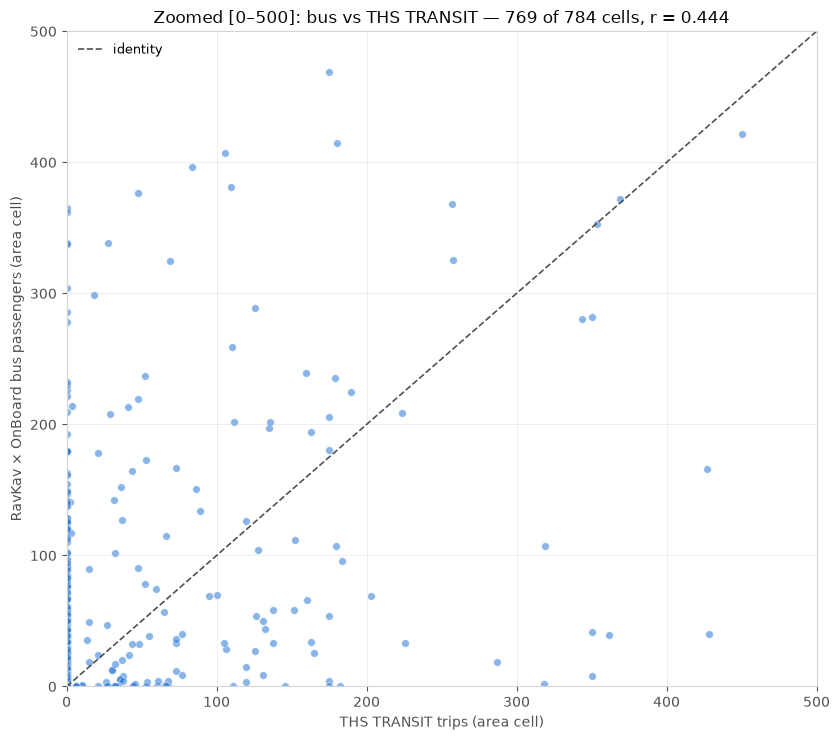

cells within [0, 500] on both axes: 769 of 784 | correlation in range: r = 0.4445


In [6]:
# zoomed scatter: cells within 500 trips on both axes
mask500 = (b <= 500) & (t <= 500)
r500 = np.corrcoef(t[mask500], b[mask500])[0, 1]

fig, ax = plt.subplots(figsize=(8.5, 7.5), facecolor='white')
ax.scatter(t[mask500], b[mask500], s=30, alpha=0.55, color=BLUE, edgecolors='white', linewidths=0.5)
ax.plot([0, 500], [0, 500], linestyle='--', linewidth=1.2, color=INK2, label='identity')
ax.set_xlim(0, 500); ax.set_ylim(0, 500)
ax.set_xlabel('THS TRANSIT trips (area cell)', color=INK2)
ax.set_ylabel('RavKav × OnBoard bus passengers (area cell)', color=INK2)
ax.set_title(f'Zoomed [0–500]: bus vs THS TRANSIT — {mask500.sum()} of {len(b)} cells, r = {r500:.3f}', color=INK, fontsize=12)
ax.grid(True, alpha=0.25, linewidth=0.6)
for s in ax.spines.values(): s.set_color('#d5d4d0')
ax.tick_params(colors=INK2)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig('Output/figures/bus_vs_ths_transit_area_zoom500.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"cells within [0, 500] on both axes: {mask500.sum()} of {len(b)} | correlation in range: r = {r500:.4f}")

## Filtering out noise areas

Areas with very little RavKav activity are statistical noise (a handful of taps per day). The activity distribution has a clean break: Tzipori (35), Adi (44), Alon Hagalil (55) total daily origins+destinations, then a jump to 109+. Areas below **50** total activity (trips) are removed.

removed areas: {20: 'Adi (44)', 22: 'Tzipori (35)'}
filtered matrix: (26, 26), 41,272 passengers (79 removed = 0.19% of volume)
correlation vs THS TRANSIT (filtered areas): full r = 0.7533 | within [0,500] r = 0.4311


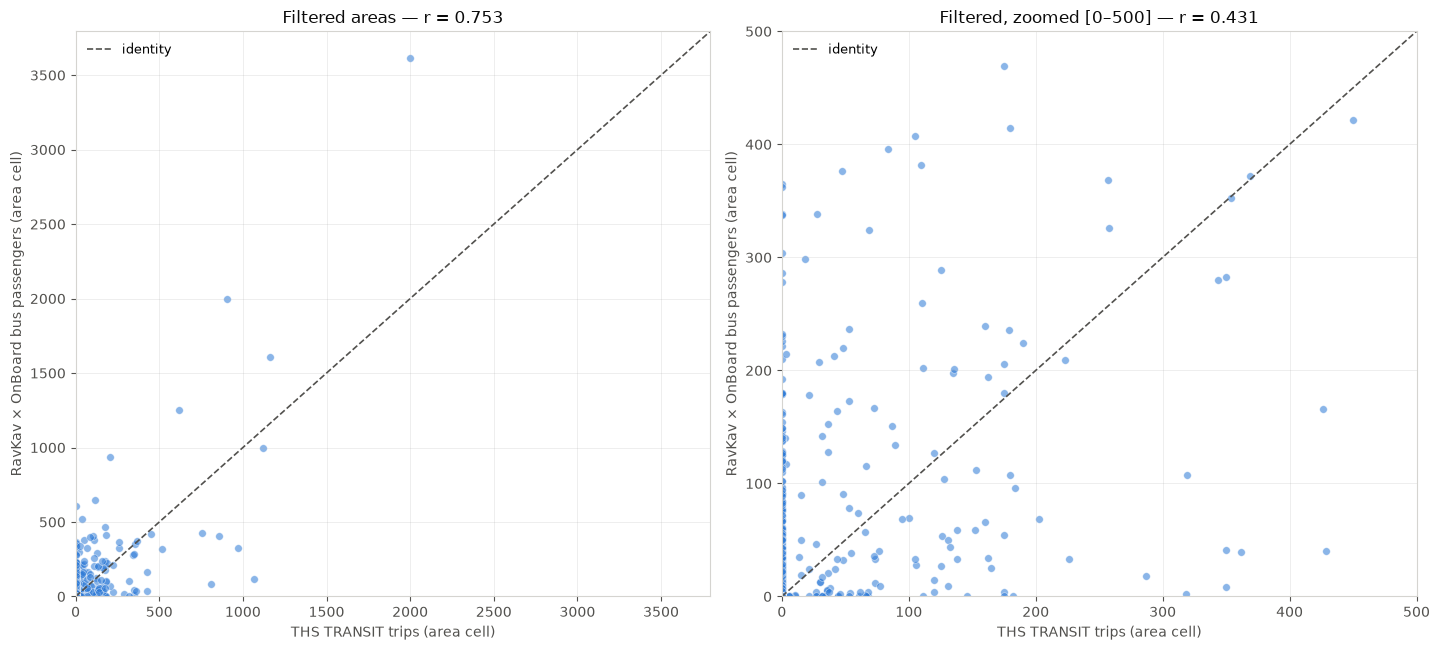

In [7]:
MIN_ACTIVITY = 50
activity = bus_area.sum(axis=1) + bus_area.sum(axis=0)
noise_areas = activity[activity < MIN_ACTIVITY].index.tolist()
keep = [a for a in AREAS if a not in noise_areas]
print("removed areas:", {a: f"{legend[a]} ({activity[a]:,.0f})" for a in noise_areas})

bus_area_f = bus_area.loc[keep, keep]
bus_area_f.index.name = 'AggAreaCode'
bus_area_f.to_csv('Output/bus/bus_od_area_new_filtered.csv', float_format='%.6g')
print(f"filtered matrix: {bus_area_f.shape}, {bus_area_f.values.sum():,.0f} passengers "
      f"({bus_area.values.sum() - bus_area_f.values.sum():,.0f} removed = "
      f"{1 - bus_area_f.values.sum() / bus_area.values.sum():.2%} of volume)")

# comparison vs THS TRANSIT on the retained areas
ths_f = ths.loc[keep, keep]
bf, tf = bus_area_f.values.flatten(), ths_f.values.flatten()
r_f = np.corrcoef(tf, bf)[0, 1]
m500 = (bf <= 500) & (tf <= 500)
r_f500 = np.corrcoef(tf[m500], bf[m500])[0, 1]
print(f"correlation vs THS TRANSIT (filtered areas): full r = {r_f:.4f} | within [0,500] r = {r_f500:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14.5, 6.6), facecolor='white')
for ax, (xx, yy, lim, title) in zip(axes, [
        (tf, bf, max(bf.max(), tf.max()) * 1.05, f'Filtered areas — r = {r_f:.3f}'),
        (tf[m500], bf[m500], 500, f'Filtered, zoomed [0–500] — r = {r_f500:.3f}')]):
    ax.scatter(xx, yy, s=30, alpha=0.55, color=BLUE, edgecolors='white', linewidths=0.5)
    ax.plot([0, lim], [0, lim], linestyle='--', linewidth=1.2, color=INK2, label='identity')
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel('THS TRANSIT trips (area cell)', color=INK2)
    ax.set_ylabel('RavKav × OnBoard bus passengers (area cell)', color=INK2)
    ax.set_title(title, color=INK, fontsize=12)
    ax.grid(True, alpha=0.25, linewidth=0.6)
    for s in ax.spines.values(): s.set_color('#d5d4d0')
    ax.tick_params(colors=INK2)
    ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig('Output/figures/bus_vs_ths_transit_area_filtered.png', dpi=150, bbox_inches='tight')
plt.show()

## Notes

- The "new" matrix keeps RavKav's origin volumes (total 143,402 average-Tuesday passengers, asserted preserved) and replaces the destination pattern with the OnBoard survey's probabilities wherever available.
- The OnBoard file's unknown-alighting share (`toTAZ` = NaN) is removed by row renormalization — i.e., unknown alightings are assumed to distribute like the known ones of the same origin.
- Origins without OnBoard coverage (142 zones, 5.0% of volume) and origins whose OnBoard row is entirely unknown-destination keep their RavKav distribution.